# Mutual Information Analysis

This notebook calculates the Mutual Information (MI) between the learned latent space and the most important residues (identified via attention weights).

Specifically:
1. Selects the top 3-10 residues based on median attention.
2. Calculates the MI between the latent components (Z) and the dihedral angles (phi, psi) of these residues.
3. Identifies the 2 dihedral angles (phi or psi) with the highest MI relative to the latent space.
4. Compares MI(phi) vs MI(psi) for the residues involved.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md
from pathlib import Path
from sklearn.feature_selection import mutual_info_regression
import sys

# Add path for pkgs
sys.path.append(str(Path('../../').resolve()))
from pkgs.utils import compute_aligned_phi_psi

# Configurations (modify K_TOP between 3 and 10 as requested)
OUTPUT_DIR = Path('../test05/output')
TRAJ_PATH = Path('../test05/traj_skip100NoH.xtc')
TOP_PATH = Path('../test05/2JOF-0-proteinNoH.pdb')
K_TOP = 10   # choose a value between 3 and 10

assert OUTPUT_DIR.exists(), f"Missing {OUTPUT_DIR}"
assert TRAJ_PATH.exists(), f"Missing {TRAJ_PATH}"
assert TOP_PATH.exists(), f"Missing {TOP_PATH}"


## Data loading and residue selection


In [2]:
# Load latents
Z = np.load(OUTPUT_DIR / 'latents.npy')  # (T, latent_dim)
print('Latents shape:', Z.shape)

# Load residue importance (residue_id, w_mean, w_median)
df_attn = pd.read_csv(OUTPUT_DIR / 'attn_importance_by_residue.txt',
                      sep='\s+', comment='#', names=['residue_id', 'w_mean', 'w_median'])

# Sort by median (robust importance) and select top-K
assert 3 <= K_TOP <= 10, 'K_TOP must be between 3 and 10'
df_attn_top = df_attn.sort_values('w_median', ascending=False).head(K_TOP).reset_index(drop=True)

top_residue_ids = df_attn_top['residue_id'].values.astype(int)
print("Top residues by median attention (K=", K_TOP, "):")
display(df_attn_top)


Latents shape: (10440, 2)
Top residues by median attention (K= 10 ):


,residue_id,w_mean,w_median
0,17,0.073108,0.072572
1,18,0.071992,0.070082
2,16,0.071039,0.068942
3,15,0.068182,0.066307
4,14,0.072730,0.066082
5,11,0.065965,0.064577
6,13,0.064093,0.062861
7,10,0.068749,0.061933
8,12,0.063257,0.061810
9,1,0.058125,0.058157


## Dihedral angles calculation for selected residues


In [3]:
print("Loading trajectory and computing angles...")
traj = md.load(str(TRAJ_PATH), top=str(TOP_PATH))
phi, psi, residue_ids, _ = compute_aligned_phi_psi(traj)  # (T, N_tokens)

# Filter for top residues only
mask_top = np.isin(residue_ids, top_residue_ids)
phi_top = phi[:, mask_top]
psi_top = psi[:, mask_top]
res_ids_top = residue_ids[mask_top].astype(int)

print(f"Angles computed for {len(res_ids_top)} residues.")
assert phi_top.shape[0] == Z.shape[0], 'Mismatch: Z frames and angles frames do not match'


Loading trajectory and computing angles...
Angles computed for 10 residues.


## Mutual Information (MI) Calculation

We calculate the MI between each angle (phi, psi) and the latent space. The MI is summed across individual latent dimensions (Z[:, i]).


In [4]:
def calculate_mi_with_latent(angle_data: np.ndarray, latent_space: np.ndarray) -> float:
    """
    angle_data: (T,)
    latent_space: (T, d)
    Returns the sum of MI between angle_data and each latent dimension.
    """
    total_mi = 0.0
    for i in range(latent_space.shape[1]):
        mi = mutual_info_regression(angle_data.reshape(-1, 1), latent_space[:, i], random_state=42)
        total_mi += float(mi[0])
    return float(total_mi)

mi_results = []
for i, res_id in enumerate(res_ids_top):
    print(f"Calculating MI for residue {int(res_id)}...")
    mi_phi = calculate_mi_with_latent(phi_top[:, i], Z)
    mi_psi = calculate_mi_with_latent(psi_top[:, i], Z)
    mi_results.append({
        'residue_id': int(res_id),
        'mi_phi': mi_phi,
        'mi_psi': mi_psi,
        'mi_total': mi_phi + mi_psi
    })

df_mi = pd.DataFrame(mi_results).sort_values('mi_total', ascending=False).reset_index(drop=True)
display(df_mi)

# Save results
out_csv = OUTPUT_DIR / 'mi_phi_psi_vs_latent.csv'
df_mi.to_csv(out_csv, index=False)
print('Saved:', out_csv)


Calculating MI for residue 1...
Calculating MI for residue 10...
Calculating MI for residue 11...
Calculating MI for residue 12...
Calculating MI for residue 13...
Calculating MI for residue 14...
Calculating MI for residue 15...
Calculating MI for residue 16...
Calculating MI for residue 17...
Calculating MI for residue 18...


,residue_id,mi_phi,mi_psi,mi_total
0,10,0.777167,0.862767,1.639934
1,14,0.610846,0.350243,0.961089
2,12,0.350056,0.605042,0.955098
3,13,0.125282,0.549682,0.674964
4,11,0.072530,0.519361,0.591890
5,1,0.125860,0.375408,0.501269
6,15,0.083989,0.068922,0.152912
7,16,0.012897,0.043413,0.056310
8,18,0.013162,0.005485,0.018647
9,17,0.002610,0.011789,0.014399


Saved: ../test05/output/mi_phi_psi_vs_latent.csv


## Analysis of the top 2 residues

We identify the 2 residues that participate most in the formation of the latent space according to MI, and compare mi_phi vs mi_psi.


Top 2 individual dihedrals by Mutual Information:


,name,mi
0,Residue 10 psi,0.862767
1,Residue 10 phi,0.777167


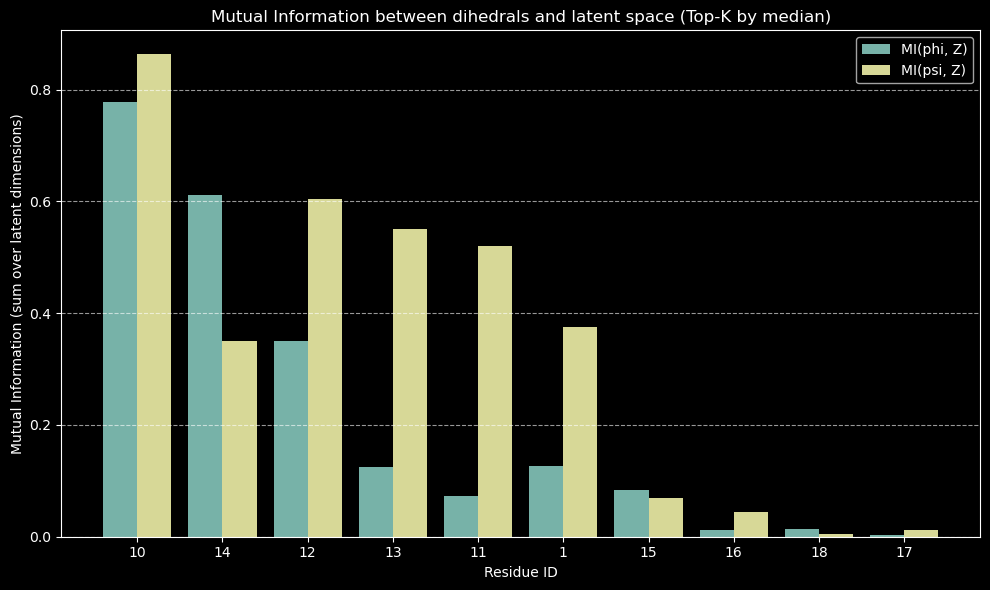

Figure saved to: ../test05/output/mi_phi_psi_vs_latent_bar.png


In [5]:
# Identify the top 2 individual dihedral angles (global ranking)
all_angles = []
for _, row in df_mi.iterrows():
    all_angles.append({'name': f"Residue {int(row['residue_id'])} phi", 'mi': row['mi_phi']})
    all_angles.append({'name': f"Residue {int(row['residue_id'])} psi", 'mi': row['mi_psi']})

df_all_angles = pd.DataFrame(all_angles).sort_values('mi', ascending=False).reset_index(drop=True)

print("Top 2 individual dihedrals by Mutual Information:")
display(df_all_angles.head(2))

# Identify the top 2 residues by total MI for backward compatibility/plotting
top_2_mi = df_mi.head(2).copy()

# Plot results
plt.figure(figsize=(10, 6))
x = np.arange(len(df_mi))
plt.bar(x - 0.2, df_mi['mi_phi'], width=0.4, label='MI(phi, Z)', alpha=0.85)
plt.bar(x + 0.2, df_mi['mi_psi'], width=0.4, label='MI(psi, Z)', alpha=0.85)
plt.xticks(x, df_mi['residue_id'].astype(int))
plt.xlabel('Residue ID')
plt.ylabel('Mutual Information (sum over latent dimensions)')
plt.title('Mutual Information between dihedrals and latent space (Top-K by median)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

fig_path = OUTPUT_DIR / 'mi_phi_psi_vs_latent_bar.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to:', fig_path)


## Conclusions

For the top two residues, we indicate which between phi and psi has the higher MI (thus contributing more to the latent space according to this metric).


In [6]:
for _, row in top_2_mi.iterrows():
    res_id = int(row['residue_id'])
    winner = 'phi' if row['mi_phi'] > row['mi_psi'] else 'psi'
    diff = abs(row['mi_phi'] - row['mi_psi'])
    print(f"Residue {res_id}: {winner} contributes more (MI diff: {diff:.6f})")
    print(f"  MI phi: {row['mi_phi']:.6f}")
    print(f"  MI psi: {row['mi_psi']:.6f}")
    print('-' * 30)

print("="*50)
print("FINAL SUMMARY: MOST INFORMATIVE DIHEDRALS")
print("="*50)
for i, row in df_all_angles.head(4).iterrows():
    print(f"Rank {i+1}: {row['name']} (MI: {row['mi']:.6f})")
print("="*50)


Residue 10: psi contributes more (MI diff: 0.085601)
  MI phi: 0.777167
  MI psi: 0.862767
------------------------------
Residue 14: phi contributes more (MI diff: 0.260604)
  MI phi: 0.610846
  MI psi: 0.350243
------------------------------
FINAL SUMMARY: MOST INFORMATIVE DIHEDRALS
Rank 1: Residue 10 psi (MI: 0.862767)
Rank 2: Residue 10 phi (MI: 0.777167)
Rank 3: Residue 14 phi (MI: 0.610846)
Rank 4: Residue 12 psi (MI: 0.605042)
